# ⚙️ Pack Engenheiro 4.0 — Curadoria Bibliométrica

**Objetivo:** Documentar o pipeline de triagem manual que selecionou 14 estudos de caso  
a partir de 25 artigos recuperados no Web of Science (WoS) sobre aplicações práticas  
da Indústria 4.0 na Engenharia de Produção.

**Fonte:** Web of Science — Coleção Principal (Clarivate)  
**Data da busca:** 18/03/2025  
**String de busca:**
```
TS=(("Industry 4.0" OR
"Smart Manufacturing") AND ("Production Engineering"
OR "Industrial Engineering" OR
"Manufacturing Management") AND
("Case Study" OR "Implementation"
OR "Pilot Project")) and Acesso Aberto

```

## 1. Setup

In [2]:
!pip install rispy -q

import rispy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


## 2. Carregamento e parsing do arquivo RIS

Arquivo exportado do WoS em formato RIS. Renomeie para `savedrecs.ris` e  
coloque na pasta `data/` antes de executar.

In [4]:
# Ajuste o caminho conforme seu ambiente
# Local: '/content/savedrecs.ris'

CAMINHO_RIS = '/content/savedrecs.ris'

with open(CAMINHO_RIS, 'r', encoding='utf-8-sig') as f:
    entries = rispy.load(f)

print(f"📄 Total de registros carregados: {len(entries)}")

📄 Total de registros carregados: 25


## 3. Construção do DataFrame

In [5]:
def extract_citations(notes):
    """Extrai total de citações das notas do WoS."""
    for n in notes:
        if 'Total Times Cited' in n:
            match = re.search(r'Total Times Cited:\s*(\d+)', n)
            if match:
                return int(match.group(1))
    return 0

def extract_wos_index(unknown_tag):
    """Extrai índice WoS do campo desconhecido."""
    we = unknown_tag.get('WE', [])
    if not we:
        return 'Não indexado'
    # Prioridade: SCI > SSCI > ESCI > CPCI
    for idx in ['Science Citation Index Expanded', 'Social Science Citation Index',
                'Emerging Sources Citation Index', 'Conference Proceedings']:
        for w in we:
            if idx[:15] in w:
                return idx.split('(')[0].strip()
    return we[0]

records = []
for e in entries:
    ut = e.get('unknown_tag', {})
    records.append({
        'accession_number': e.get('accession_number', ''),
        'title':            e.get('title', ''),
        'authors':          '; '.join(e.get('authors', [])[:3]) + (' et al.' if len(e.get('authors',[])) > 3 else ''),
        'journal':          e.get('secondary_title', ''),
        'year':             int(e.get('year', 0)),
        'doi':              e.get('doi', ''),
        'keywords':         e.get('keywords', []),
        'abstract':         e.get('abstract', ''),
        'doc_type':         e.get('type_of_reference', 'JOUR'),
        'wos_index':        extract_wos_index(ut),
        'total_cited':      extract_citations(e.get('notes', [])),
        'ref_count':        int(next((re.search(r'Cited Reference Count:\s*(\d+)', n).group(1)
                                     for n in e.get('notes', []) if 'Cited Reference Count' in n), 0)),
    })

df = pd.DataFrame(records)
print(f"✅ DataFrame criado: {df.shape[0]} artigos × {df.shape[1]} colunas")
df[['year','journal','total_cited','wos_index']].head(10)

✅ DataFrame criado: 25 artigos × 12 colunas


,year,journal,total_cited,wos_index
0,2025,JORDAN JOURNAL OF MECHANICAL AND INDUSTRIAL EN...,0,Emerging Sources Citation Index
1,2024,JOURNAL OF MANUFACTURING AND MATERIALS PROCESSING,0,Emerging Sources Citation Index
2,2023,REVISTA DE GESTAO E SECRETARIADO-GESEC,2,Emerging Sources Citation Index
3,2022,COGENT EDUCATION,2,Emerging Sources Citation Index
4,2023,IEEE ACCESS,6,Science Citation Index Expanded
5,2023,APPLIED SCIENCES-BASEL,51,Science Citation Index Expanded
6,2025,COMPUTERS,0,Emerging Sources Citation Index
7,2025,SUSTAINABILITY,0,Science Citation Index Expanded
8,2023,MACHINES,9,Science Citation Index Expanded
9,2024,JORDAN JOURNAL OF MECHANICAL AND INDUSTRIAL EN...,11,Emerging Sources Citation Index


In [ ]:
df

,accession_number,title,authors,journal,year,doi,keywords,abstract,doc_type,wos_index,total_cited,ref_count,selecionado
0,WOS:001513142800005,Strategic Roadmap for Prioritizing Industry 4....,"Aoufi, T; Aksa, K",JORDAN JOURNAL OF MECHANICAL AND INDUSTRIAL EN...,2025,10.59038/jjmie/190205,"[Industry 4.0, Decision-making Methods, Techno...","Industry 4.0, also known as the Fourth Industr...",JOUR,Emerging Sources Citation Index,0,56,True
1,WOS:001340875800001,A Universal Framework for Skill-Based Cyber-Ph...,"Hossfeld, M; Wortmann, A",JOURNAL OF MANUFACTURING AND MATERIALS PROCESSING,2024,10.3390/jmmp8050221,"[automated production planning, model-driven d...",In the vision of smart manufacturing and Indus...,JOUR,Emerging Sources Citation Index,0,86,True
2,WOS:001003293800005,Technology and Industry 4.0 in production engi...,"da Matta, GA; Alves, MD; de Oliveira, NC et al.",REVISTA DE GESTAO E SECRETARIADO-GESEC,2023,10.7769/gesec.v14i4.2057,"[Technology Innovation, 4, 0 Industry, Product...","The acronym ""vuca"" has been increasingly incor...",JOUR,Emerging Sources Citation Index,2,31,True
3,WOS:000822290900001,A gap study between industry expectations and ...,"Chaengpromma, N; Pattanapairoj, S",COGENT EDUCATION,2022,10.1080/2331186X.2022.2093491,"[gap study, industry 4.0 competency indicators...",The purpose of this research is to study the g...,JOUR,Emerging Sources Citation Index,2,25,False
4,WOS:001045243800001,Application of Fuzzy TOPSIS and Harmonic Mitig...,"Duc, ML; Nedoma, J; Bilik, P et al.",IEEE ACCESS,2023,10.1109/ACCESS.2023.3299326,"[RFID, smart manufacturing, six sigma, hybrid ...",Customers' requirements for product quality ar...,JOUR,Science Citation Index Expanded,6,73,False
5,WOS:000933779000001,Machine Learning in Manufacturing towards Indu...,"Chen, TT; Sampath, V; May, MC et al.",APPLIED SCIENCES-BASEL,2023,10.3390/app13031903,"[machine learning, Industry 4, 0, manufacturin...",While attracting increasing research attention...,JOUR,Science Citation Index Expanded,51,228,True
6,WOS:001646266600001,Digital Tech Integration in Industrial Enginee...,"Belmonte, LM; Segura, E; Gomez-Sirvent, JL et al.",COMPUTERS,2025,10.3390/computers14120547,"[Industry 4.0 concepts, teaching-learning meth...",The rapid advancement of Industry 4.0 and digi...,JOUR,Emerging Sources Citation Index,0,124,True
7,WOS:001593881400001,A Data-Driven Approach to Lean and Digital Pro...,"Matias, F; Miranda, S; Yildiz, O et al.",SUSTAINABILITY,2025,10.3390/su17198888,"[data-driven lean management, re-business proc...",This study presents a data-driven framework th...,JOUR,Science Citation Index Expanded,0,50,True
8,WOS:001073992100001,Ergonomic Design of an Adaptive Automation Ass...,"Bortolini, M; Botti, L; Galizia, FG et al.",MACHINES,2023,10.3390/machines11090898,"[adaptive automation assembly systems, smart m...",Ergonomics is a key factor in the improvement ...,JOUR,Science Citation Index Expanded,9,49,False
9,WOS:001246670000008,Integrating Supply Chain Partners through Impl...,"Rashed, CA; Bagum, N; Kibria, MMH et al.",JORDAN JOURNAL OF MECHANICAL AND INDUSTRIAL EN...,2024,10.59038/jjmie/180208,"[Industry 4.0 technology, Supply Chain Partner...",Manufacturing companies must embrace state-of-...,JOUR,Emerging Sources Citation Index,11,91,True


## 4. Análise Exploratória — Base Completa (25 artigos)

In [6]:
print("=== VISÃO GERAL ===")
print(f"Período: {df.year.min()}–{df.year.max()}")
print(f"Periódicos únicos: {df.journal.nunique()}")
print(f"Total de citações (soma): {df.total_cited.sum()}")
print(f"\nDistribuição por índice WoS:")
print(df.wos_index.value_counts().to_string())
print(f"\nDistribuição por tipo:")
print(df.doc_type.value_counts().to_string())

=== VISÃO GERAL ===
Período: 2022–2025
Periódicos únicos: 19
Total de citações (soma): 220

Distribuição por índice WoS:
wos_index
Science Citation Index Expanded    15
Emerging Sources Citation Index     9
Social Science Citation Index       1

Distribuição por tipo:
doc_type
JOUR      24
CPAPER     1


### 4.1 Distribuição por ano

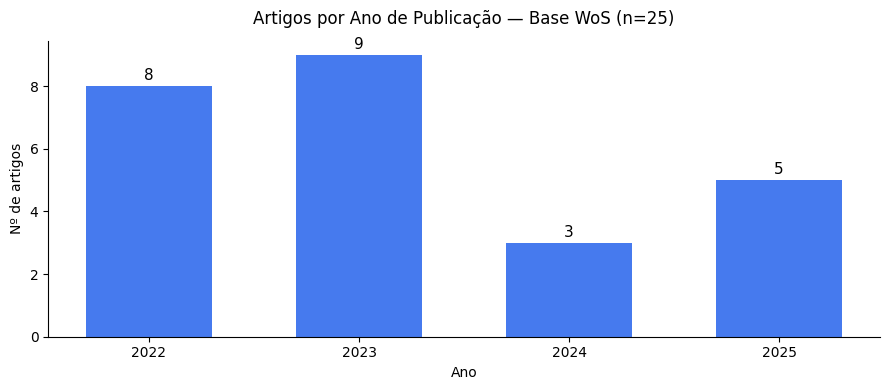

✅ Salvo: assets/graficos/artigos_por_ano.png


In [7]:
import os

fig, ax = plt.subplots(figsize=(9, 4))
year_counts = df.year.value_counts().sort_index()
bars = ax.bar(year_counts.index, year_counts.values,
              color='#2563EB', alpha=0.85, width=0.6)
for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom', fontsize=11)
ax.set_title('Artigos por Ano de Publicação — Base WoS (n=25)', pad=12)
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de artigos')
ax.set_xticks(year_counts.index)
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs('assets/graficos', exist_ok=True)

plt.savefig('assets/graficos/artigos_por_ano.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: assets/graficos/artigos_por_ano.png")

### 4.2 Top periódicos

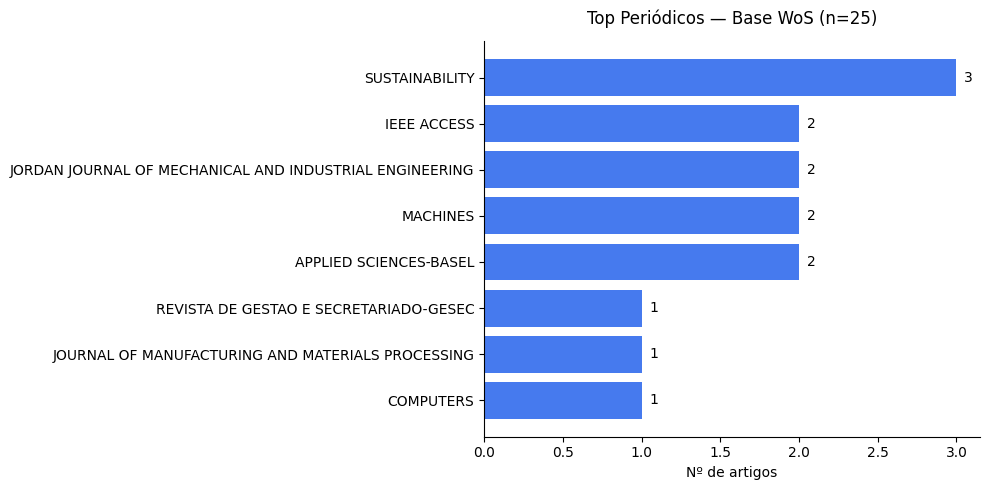

✅ Salvo: assets/graficos/top_periodicos.png


In [8]:
top_j = df.journal.value_counts().head(8)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_j.index[::-1], top_j.values[::-1], color='#2563EB', alpha=0.85)
ax.set_title('Top Periódicos — Base WoS (n=25)', pad=12)
ax.set_xlabel('Nº de artigos')
for i, v in enumerate(top_j.values[::-1]):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('assets/graficos/top_periodicos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: assets/graficos/top_periodicos.png")

### 4.3 Frequência de palavras-chave (autor)

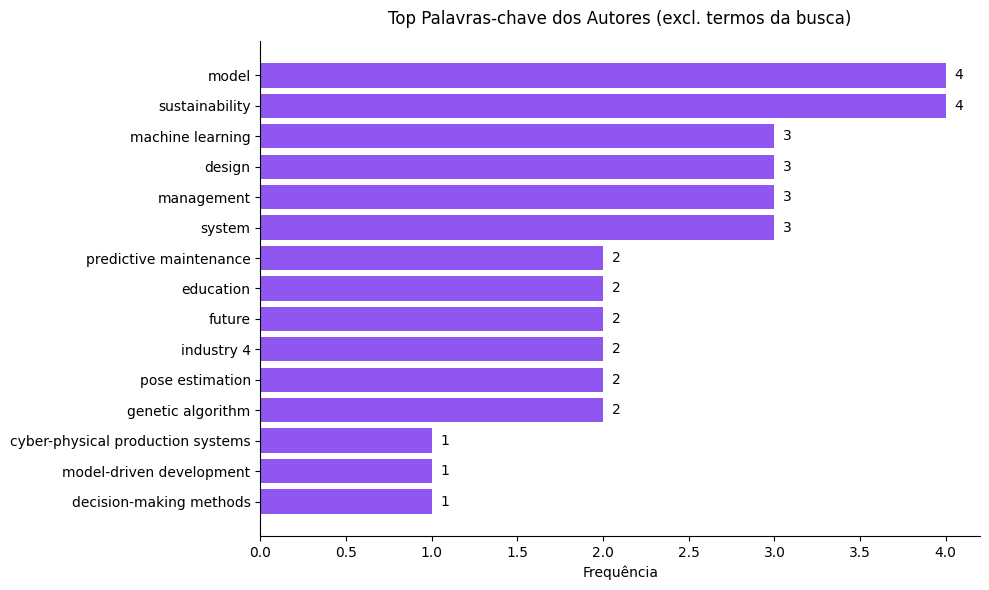

✅ Salvo: assets/graficos/top_keywords.png


In [9]:
# Flatten keywords
all_kw = [kw.lower().strip() for row in df.keywords for kw in row]
kw_counts = Counter(all_kw)

# Filtrar termos genéricos da string de busca
skip = {'industry 4.0','smart manufacturing','digital transformation',
        '4','0','manufacturing','industrial engineering'}
kw_filtered = {k: v for k, v in kw_counts.items()
               if k not in skip and len(k) > 3}

top_kw = pd.Series(kw_filtered).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_kw.index[::-1], top_kw.values[::-1], color='#7C3AED', alpha=0.85)
ax.set_title('Top Palavras-chave dos Autores (excl. termos da busca)', pad=12)
ax.set_xlabel('Frequência')
for i, v in enumerate(top_kw.values[::-1]):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('assets/graficos/top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: assets/graficos/top_keywords.png")

## 5. Triagem Manual — Critérios e Seleção

### Critérios de inclusão aplicados
A triagem foi realizada por leitura de títulos e resumos, seguindo os critérios:

1. **Estudo de caso real** — implementação em empresa/instituição identificável
2. **Tecnologia habilitadora aplicada** — não apenas conceitual ou teórico
3. **Contexto de engenharia de produção** — processos, sistemas, qualidade, logística
4. **Resultados mensuráveis** — métricas de desempenho reportadas

### Critérios de exclusão
- Foco exclusivo em educação de engenharia (sem aplicação industrial)
- Artigos de conferência (baixo rigor de revisão)
- Contribuição majoritariamente teórica/metodológica sem validação em caso real

---
**⚙️ Preencha a lista abaixo com os accession numbers WoS dos 14 artigos selecionados.**

In [17]:
# ─────────────────────────────────────────────────────────────────────────
# PREENCHA AQUI com os accession numbers dos 13 artigos selecionados
# Você encontra o accession number na coluna 'accession_number' do DataFrame
# ou nos metadados exportados do WoS (campo AN)
# ─────────────────────────────────────────────────────────────────────────

SELECIONADOS_AN = [
    "WOS:001340875800001",
    "WOS:001003293800005",
    "WOS:000933779000001",
    "WOS:001646266600001",
    "WOS:001593881400001",
    "WOS:001246670000008",
    "WOS:000774726300001",
    "WOS:000799432000001",
    "WOS:001094733600009",
    "WOS:000817483000001",
    "WOS:001486559000001",
    "WOS:000850983500001",
    "WOS:001513142800005"
]

# Lista de verificação dos accession numbers disponíveis
print("Verificando accession numbers válidos...")

for i, row in df.iterrows():
    print(f"  {i+1:2}. {row['accession_number']} | {row['title'][:60]}")

Verificando accession numbers válidos...
   1. WOS:001513142800005 | Strategic Roadmap for Prioritizing Industry 4.0 Technologies
   2. WOS:001340875800001 | A Universal Framework for Skill-Based Cyber-Physical Product
   3. WOS:001003293800005 | Technology and Industry 4.0 in production engineering
   4. WOS:000822290900001 | A gap study between industry expectations and current compet
   5. WOS:001045243800001 | Application of Fuzzy TOPSIS and Harmonic Mitigation Measurem
   6. WOS:000933779000001 | Machine Learning in Manufacturing towards Industry 4.0: From
   7. WOS:001646266600001 | Digital Tech Integration in Industrial Engineer Training via
   8. WOS:001593881400001 | A Data-Driven Approach to Lean and Digital Process Re-Modeli
   9. WOS:001073992100001 | Ergonomic Design of an Adaptive Automation Assembly System
  10. WOS:001246670000008 | Integrating Supply Chain Partners through Implementing Indus
  11. WOS:000774726300001 | An efficient industry 4.0 architecture for energy 

In [18]:
SELECIONADOS_AN

['WOS:001340875800001',
 'WOS:001003293800005',
 'WOS:000933779000001',
 'WOS:001646266600001',
 'WOS:001593881400001',
 'WOS:001246670000008',
 'WOS:000774726300001',
 'WOS:000799432000001',
 'WOS:001094733600009',
 'WOS:000817483000001',
 'WOS:001486559000001',
 'WOS:000850983500001',
 'WOS:001513142800005']

## 6. Análise Comparativa — Selecionados vs Excluídos

In [19]:
# Marcar artigos selecionados
df['selecionado'] = df['accession_number'].isin(SELECIONADOS_AN)

print(f"✅ Selecionados:  {df.selecionado.sum()}")
print(f"❌ Excluídos:    {(~df.selecionado).sum()}")
print(f"📄 Total:        {len(df)}")

if df.selecionado.sum() == 0:
    print("\n⚠️  Preencha a lista SELECIONADOS_AN na célula anterior antes de continuar.")

✅ Selecionados:  13
❌ Excluídos:    12
📄 Total:        25


In [14]:
# Comparação: citações médias
if df.selecionado.sum() > 0:
    comp = df.groupby('selecionado')['total_cited'].agg(['mean','median','sum'])
    comp.index = ['Excluídos','Selecionados']
    print("=== Citações: Selecionados vs Excluídos ===")
    print(comp.round(1).to_string())

    # Comparação por índice WoS
    print("\n=== Distribuição por índice WoS ===")
    print(pd.crosstab(df.wos_index, df.selecionado,
                      colnames=['Selecionado']).to_string())

=== Citações: Selecionados vs Excluídos ===
              mean  median  sum
Excluídos      6.9     3.0   83
Selecionados  10.5     4.0  137

=== Distribuição por índice WoS ===
Selecionado                      False  True 
wos_index                                    
Emerging Sources Citation Index      2      7
Science Citation Index Expanded      9      6
Social Science Citation Index        1      0


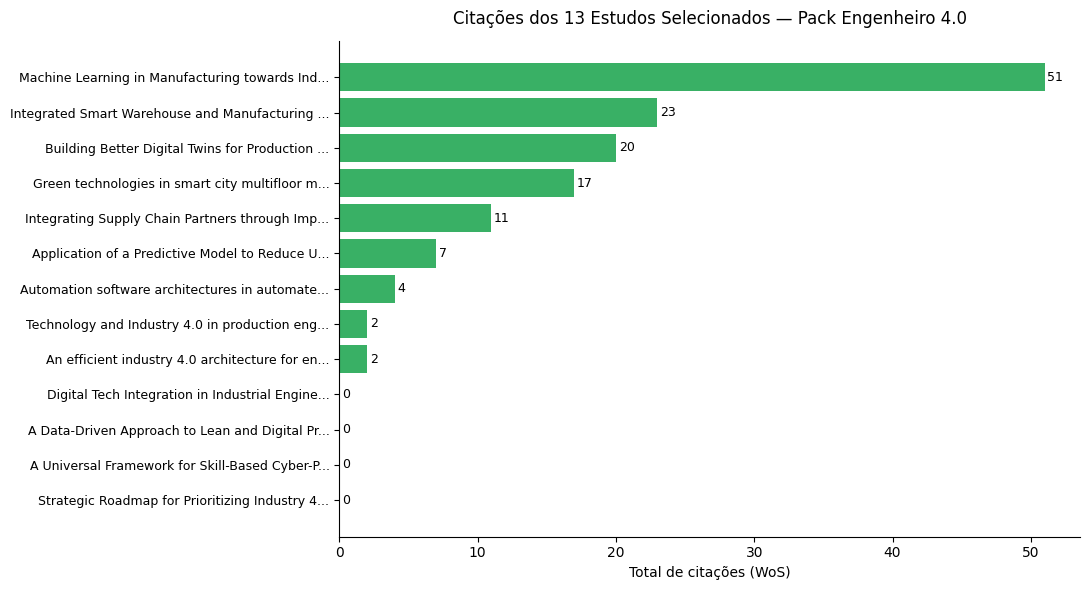

✅ Salvo: assets/graficos/citacoes_selecionados.png


In [15]:
# Gráfico: Citações dos selecionados
if df.selecionado.sum() > 0:
    sel = df[df.selecionado].sort_values('total_cited', ascending=True)
    labels = [t[:45] + '...' if len(t) > 45 else t for t in sel.title]

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(range(len(sel)), sel.total_cited, color='#16A34A', alpha=0.85)
    ax.set_yticks(range(len(sel)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f'Citações dos {len(sel)} Estudos Selecionados — Pack Engenheiro 4.0', pad=12)
    ax.set_xlabel('Total de citações (WoS)')
    for bar, val in zip(bars, sel.total_cited):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('assets/graficos/citacoes_selecionados.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Salvo: assets/graficos/citacoes_selecionados.png")

## 7. Exportação dos resultados

In [16]:
import os

# Certifica que o diretório 'outputs' existe
os.makedirs('outputs', exist_ok=True)

# Colunas para exportar
cols_export = ['accession_number','title','authors','journal','year',
               'wos_index','total_cited','ref_count','doi','selecionado']

# Base completa
df[cols_export].to_excel('outputs/base_completa_25.xlsx', index=False)
print("✅ Salvo: outputs/base_completa_25.xlsx")

# Amostra final
if df.selecionado.sum() > 0:
    df[df.selecionado][cols_export].to_excel('outputs/amostra_final_14.xlsx', index=False)
    print(f"✅ Salvo: outputs/amostra_final_14.xlsx ({df.selecionado.sum()} artigos)")
else:
    print("⚠️  Preencha SELECIONADOS_AN para gerar a amostra final.")

✅ Salvo: outputs/base_completa_25.xlsx
✅ Salvo: outputs/amostra_final_14.xlsx (13 artigos)


## 8. Resumo do pipeline

| Etapa | N |
|---|---|
| Recuperados no WoS | 25 |
| Excluídos (triagem manual) | 12 |
| **Selecionados para o Pack** | **13** |

**Critério principal de exclusão:** artigos focados em educação de engenharia e trabalhos de conferência sem aplicação industrial direta.

---
*Pipeline desenvolvido em Python + pandas para documentar a curadoria científica que fundamenta o [Pack Engenheiro 4.0](https://pack-engenheiro4-0.lovable.app/).*